In [195]:
#allow output from every line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib notebook
import seaborn as sns
import math

In [196]:
#Load all necessary files
twenty_10 = pd.read_json("2010.json")
twenty_11 = pd.read_json("2011.json")
twenty_12 = pd.read_json("2012.json")
twenty_13 = pd.read_json("2013.json")
twenty_14 = pd.read_json("2014.json")
twenty_15 = pd.read_json("2015.json")
twenty_16 = pd.read_json("2016.json")
twenty_17 = pd.read_json("2017.json")
twenty_18 = pd.read_json("2018.json")
twenty_19 = pd.read_json("2019.json")
twenty_20 = pd.read_json("2020.json")
twenty_21 = pd.read_json("2021.json")
twenty_22 = pd.read_json("2022.json")
twenty_23 = pd.read_json("2023.json")
twenty_24 = pd.read_json("2024.json")
twenty_25 = pd.read_json("2025.json")

#Batting Stats/Rosters
batting_nomin = pd.read_csv("batting_noMin.csv")
batting_qualified = pd.read_csv("batting_qualified.csv")
batting = pd.concat([batting_nomin,batting_qualified])
batting

#Pitching Stats/Rosters
pitching_nomin = pd.read_csv("pitching_noMin.csv")
pitching_qualified = pd.read_csv("pitching_qualified.csv")
pitching = pd.concat([pitching_nomin,pitching_qualified])

,name,team,team name,age,nameascii,playerid,mlbamid,year,g,ab,...,slg,ops,iso,spd,babip,wsb,wrc,wraa,woba,wrc+
0,Blake Dunn,WMU,Western Michigan University,22.0,Blake Dunn,29487,694362.0,2021,27,59,...,0.576271,1.050630,0.271186,5.438424,0.350000,0.056455,20.038378,8.258539,0.483122,170.107404
1,Ryan Bliss,AUB,Auburn University,21.0,Ryan Bliss,29547,669208.0,2021,50,211,...,0.654028,1.081995,0.289100,4.974168,0.371257,-1.456794,58.746606,20.674834,0.467360,154.304890
2,Adrian Del Castillo,MIA,University of Miami,21.0,Adrian Del Castillo,29554,680728.0,2021,54,200,...,0.395000,0.774747,0.120000,4.409581,0.304094,0.022838,35.612792,-0.514145,0.360145,98.576837
3,Tim Tawa,STAN,Stanford University,22.0,Tim Tawa,29571,694374.0,2021,52,214,...,0.518692,0.875834,0.228972,6.323953,0.304878,1.181782,41.118764,4.050893,0.390554,110.928313
4,Billy Cook,PEPP,Pepperdine University,22.0,Billy Cook,29573,695257.0,2021,33,131,...,0.725191,1.110812,0.427481,7.549825,0.301370,0.522476,36.614354,16.183401,0.474676,179.210213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11524,Anthony Mascuilli,UMBC,"University of Maryland, Baltimore County",NaN,Anthony Mascuilli,sa3066388,NaN,2025,39,132,...,0.401515,0.861742,0.098485,6.696172,0.345133,0.227533,36.666240,8.963793,0.427325,132.357406
11525,Paul Contreras,CSUF,"California State University, Fullerton",NaN,Paul Contreras,sa3066537,NaN,2025,38,143,...,0.468531,0.810146,0.209790,6.480733,0.310000,0.276773,23.388718,-1.370996,0.369565,94.462795
11526,Mac Floyd,MVSU,Mississippi Valley State University,NaN,Mac Floyd,sa3066616,NaN,2025,37,104,...,0.365385,0.726040,0.105769,6.458498,0.346667,-0.623230,15.503391,-7.153637,0.355985,68.426410
11527,Bryce Campbell,NMSU,New Mexico State University,21.0,Bryce Campbell,sa3066700,NaN,2025,39,153,...,0.477124,0.872729,0.183007,1.669496,0.339130,-0.237017,33.133894,2.618525,0.399093,108.581002


In [197]:
#create dataframe
dfs = [twenty_10, twenty_11, twenty_12, twenty_13, twenty_14, twenty_15, twenty_16, twenty_17, twenty_18, twenty_19,
      twenty_20, twenty_21, twenty_22, twenty_23, twenty_24, twenty_25]

seasons = ['2010','2011','2012','2013','2014','2015','2016','2016','2017','2018','2019','2020',
          '2021','2022','2023','2024','2025']
common_stats = set.intersection(*[set(df.index) for df in dfs])

#Transpose data to switch rows and columns
transposed = []
for df, season in zip(dfs,seasons):
    t = df.loc[list(common_stats)].transpose()
    t['Season'] = season
    transposed.append(t)
    
years = pd.concat(transposed)

#Dropped Division because it was in the rows with teams and not a column
years = years.drop(index = 'division')
years

,R (Pitching),PO,SBPG,SO,ER,DPPG,H,W,K/9,3B,...,R (Batting),BB (Batting),HA,2BPG,HR,HRPG,league,2B,FPCT,Season
Florida St. (ACC),356,1796,1.43,544,292,0.85,688,48,8.2,22,...,543,402,597,2.16,86,1.26,ACC,147,0.969,2010
New Mexico St. (WAC),511,1541,0.45,423,426,1.07,776,36,7.4,17,...,613,382,732,2.5,104,1.73,WAC,150,0.958,2010
Clemson (ACC),385,1878,1.51,486,326,1.16,764,45,7.0,15,...,600,375,684,2.07,93,1.33,ACC,145,0.963,2010
NC State (ACC),394,1664,0.68,477,326,0.94,747,38,7.7,16,...,571,333,608,2.55,98,1.58,ACC,158,0.958,2010
Arizona St. (Pac-12),248,1674,2.19,553,206,0.98,734,52,8.9,37,...,520,320,508,2.37,68,1.1,Pac-12,147,0.976,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valparaiso (MVC),445,1210,0.5,310,388,0.6,384,10,6.9,7,...,249,200,532,1.4,48,0.96,MVC,70,0.959,2024
Delaware St. (NEC),513,954,1.29,267,409,0.44,333,7,7.6,2,...,187,158,486,1.44,17,0.41,NEC,59,0.933,2024
UMES (NEC),494,1161,1.0,270,421,0.67,410,7,6.3,7,...,255,195,540,1.73,24,0.5,NEC,83,0.952,2024
Alcorn (SWAC),651,1098,3.12,227,557,0.45,447,6,5.6,15,...,298,197,596,1.86,12,0.24,SWAC,91,0.931,2024


In [198]:
#Create W/L%
years['W/L%'] = years['W']/(years['W']+years['L'])
years

,R (Pitching),PO,SBPG,SO,ER,DPPG,H,W,K/9,3B,...,BB (Batting),HA,2BPG,HR,HRPG,league,2B,FPCT,Season,W/L%
Florida St. (ACC),356,1796,1.43,544,292,0.85,688,48,8.2,22,...,402,597,2.16,86,1.26,ACC,147,0.969,2010,0.705882
New Mexico St. (WAC),511,1541,0.45,423,426,1.07,776,36,7.4,17,...,382,732,2.5,104,1.73,WAC,150,0.958,2010,0.610169
Clemson (ACC),385,1878,1.51,486,326,1.16,764,45,7.0,15,...,375,684,2.07,93,1.33,ACC,145,0.963,2010,0.642857
NC State (ACC),394,1664,0.68,477,326,0.94,747,38,7.7,16,...,333,608,2.55,98,1.58,ACC,158,0.958,2010,0.612903
Arizona St. (Pac-12),248,1674,2.19,553,206,0.98,734,52,8.9,37,...,320,508,2.37,68,1.1,Pac-12,147,0.976,2010,0.83871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valparaiso (MVC),445,1210,0.5,310,388,0.6,384,10,6.9,7,...,200,532,1.4,48,0.96,MVC,70,0.959,2024,0.2
Delaware St. (NEC),513,954,1.29,267,409,0.44,333,7,7.6,2,...,158,486,1.44,17,0.41,NEC,59,0.933,2024,0.170732
UMES (NEC),494,1161,1.0,270,421,0.67,410,7,6.3,7,...,195,540,1.73,24,0.5,NEC,83,0.952,2024,0.145833
Alcorn (SWAC),651,1098,3.12,227,557,0.45,447,6,5.6,15,...,197,596,1.86,12,0.24,SWAC,91,0.931,2024,0.122449


In [199]:
#Seperate Power 5 from Mid-Major
Power5 = ('ACC','SEC','Big Ten','Big 12','Pac-12')
years['Power5']= years['league'].isin(Power5).astype(int)
years

,R (Pitching),PO,SBPG,SO,ER,DPPG,H,W,K/9,3B,...,HA,2BPG,HR,HRPG,league,2B,FPCT,Season,W/L%,Power5
Florida St. (ACC),356,1796,1.43,544,292,0.85,688,48,8.2,22,...,597,2.16,86,1.26,ACC,147,0.969,2010,0.705882,1
New Mexico St. (WAC),511,1541,0.45,423,426,1.07,776,36,7.4,17,...,732,2.5,104,1.73,WAC,150,0.958,2010,0.610169,0
Clemson (ACC),385,1878,1.51,486,326,1.16,764,45,7.0,15,...,684,2.07,93,1.33,ACC,145,0.963,2010,0.642857,1
NC State (ACC),394,1664,0.68,477,326,0.94,747,38,7.7,16,...,608,2.55,98,1.58,ACC,158,0.958,2010,0.612903,1
Arizona St. (Pac-12),248,1674,2.19,553,206,0.98,734,52,8.9,37,...,508,2.37,68,1.1,Pac-12,147,0.976,2010,0.83871,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Valparaiso (MVC),445,1210,0.5,310,388,0.6,384,10,6.9,7,...,532,1.4,48,0.96,MVC,70,0.959,2024,0.2,0
Delaware St. (NEC),513,954,1.29,267,409,0.44,333,7,7.6,2,...,486,1.44,17,0.41,NEC,59,0.933,2024,0.170732,0
UMES (NEC),494,1161,1.0,270,421,0.67,410,7,6.3,7,...,540,1.73,24,0.5,NEC,83,0.952,2024,0.145833,0
Alcorn (SWAC),651,1098,3.12,227,557,0.45,447,6,5.6,15,...,596,1.86,12,0.24,SWAC,91,0.931,2024,0.122449,0


In [200]:
#Calculate standard deviation of win percentage
team_consistency = years.groupby('team')['W/L%'].std().reset_index()
team_consistency.columns = ['team','W/L%_std']
team_consistency

#Bring Power 5 label into team_consistency
labels = years[['team','Power5']].drop_duplicates()
team_consistency = team_consistency.merge(labels, on = 'team')
team_consistency

,team,W/L%_std
0,A&M-Corpus Christi,0.074150
1,Abilene Christian,0.080637
2,Air Force,0.100618
3,Akron,0.109170
4,Alabama,0.131918
...,...,...
310,Wofford,0.141535
311,Wright St.,0.097464
312,Xavier,0.089112
313,Yale,0.113875


,team,W/L%_std,Power5
0,A&M-Corpus Christi,0.074150,0
1,Abilene Christian,0.080637,0
2,Air Force,0.100618,0
3,Akron,0.109170,0
4,Alabama,0.131918,1
...,...,...,...
323,Wofford,0.141535,0
324,Wright St.,0.097464,0
325,Xavier,0.089112,0
326,Yale,0.113875,0


In [201]:
#Calculate total number of games per team
games_per_team = years.groupby('team')['G'].sum().reset_index()
games_per_team.columns = ('team','total_games')

games_per_team['ideal_std'] = 0.5/(games_per_team['total_games'].apply(math.sqrt))

combined = games_per_team.merge(team_consistency, on = 'team')
combined

,team,total_games,ideal_std,W/L%_std,Power5
0,A&M-Corpus Christi,848,0.017170,0.074150,0
1,Abilene Christian,411,0.024663,0.080637,0
2,Air Force,835,0.017303,0.100618,0
3,Akron,613,0.020195,0.109170,0
4,Alabama,906,0.016611,0.131918,1
...,...,...,...,...,...
323,Wofford,891,0.016751,0.141535,0
324,Wright St.,877,0.016884,0.097464,0
325,Xavier,886,0.016798,0.089112,0
326,Yale,606,0.020311,0.113875,0


In [215]:
#Sort batting by player and year
batting_sorted = batting.sort_values(['name', 'year'])

#See which players were on previous teams in years prior
batting_sorted['prev_team'] = batting_sorted.groupby('name')['team name'].shift(1)
batting_sorted['prev_year'] = batting_sorted.groupby('name')['year'].shift(1)

#Find how many transfers there are total in the batting data
batting_sorted['is_transfer'] = (
    (batting_sorted['team name'] != batting_sorted['prev_team']) & 
    (batting_sorted['year'] == batting_sorted['prev_year'] + 1) &
    (batting_sorted['prev_team'].notna())
)

transfers = batting_sorted[batting_sorted['is_transfer']]
print(f"Total batting transfers: {len(transfers)}")

#sort pitching data by player and year
pitching_sorted = pitching.sort_values(['name', 'year'])

#Find which pitchers were on other rosters in previous years
pitching_sorted['prev_team'] = pitching_sorted.groupby('name')['team name'].shift(1)
pitching_sorted['prev_year'] = pitching_sorted.groupby('name')['year'].shift(1)

#Find how many transfers there are total in the pitching data
pitching_sorted['is_transfer'] = (
    (pitching_sorted['team name'] != pitching_sorted['prev_team']) & 
    (pitching_sorted['year'] == pitching_sorted['prev_year'] + 1) &
    (pitching_sorted['prev_team'].notna())
)
#Print outcome
transfers_p = pitching_sorted[pitching_sorted['is_transfer']]
print(f"Total pitching transfers: {len(transfers_p)}")

Total batting transfers: 1746
Total pitching transfers: 1737


In [222]:
power5 = {'ACC', 'Big Ten', 'Big 12', 'SEC', 'Pac-12'}

total_transfers = pd.concat([transfers, transfers_p])
# You'll need a conference lookup -- merge from your years DataFrame
team_conference = years[['team', 'league']].drop_duplicates()
team_conference.columns = ['team name', 'league']

total_transfers = total_transfers.merge(team_conference, on='team name', how='left')

# Find number of transfers into Power 5 conferences
transfers_to_p5 = total_transfers[total_transfers['league'].isin(power5)]
#Find number of transfers into Mid-Major Conferences
transfers_to_nonp5 = total_transfers[~total_transfers['league'].isin(power5)]


#Print transfers into Power 5 and Mid-Major conferences by year
print(transfers_to_nonp5.groupby('year')['name'].count())
print(transfers_to_p5.groupby('year')['name'].count())




year
2022     693
2023     805
2024     916
2025    1060
Name: name, dtype: int64
year
2022     8
2023     7
2024    11
2025    14
Name: name, dtype: int64


<IPython.core.display.Javascript object>


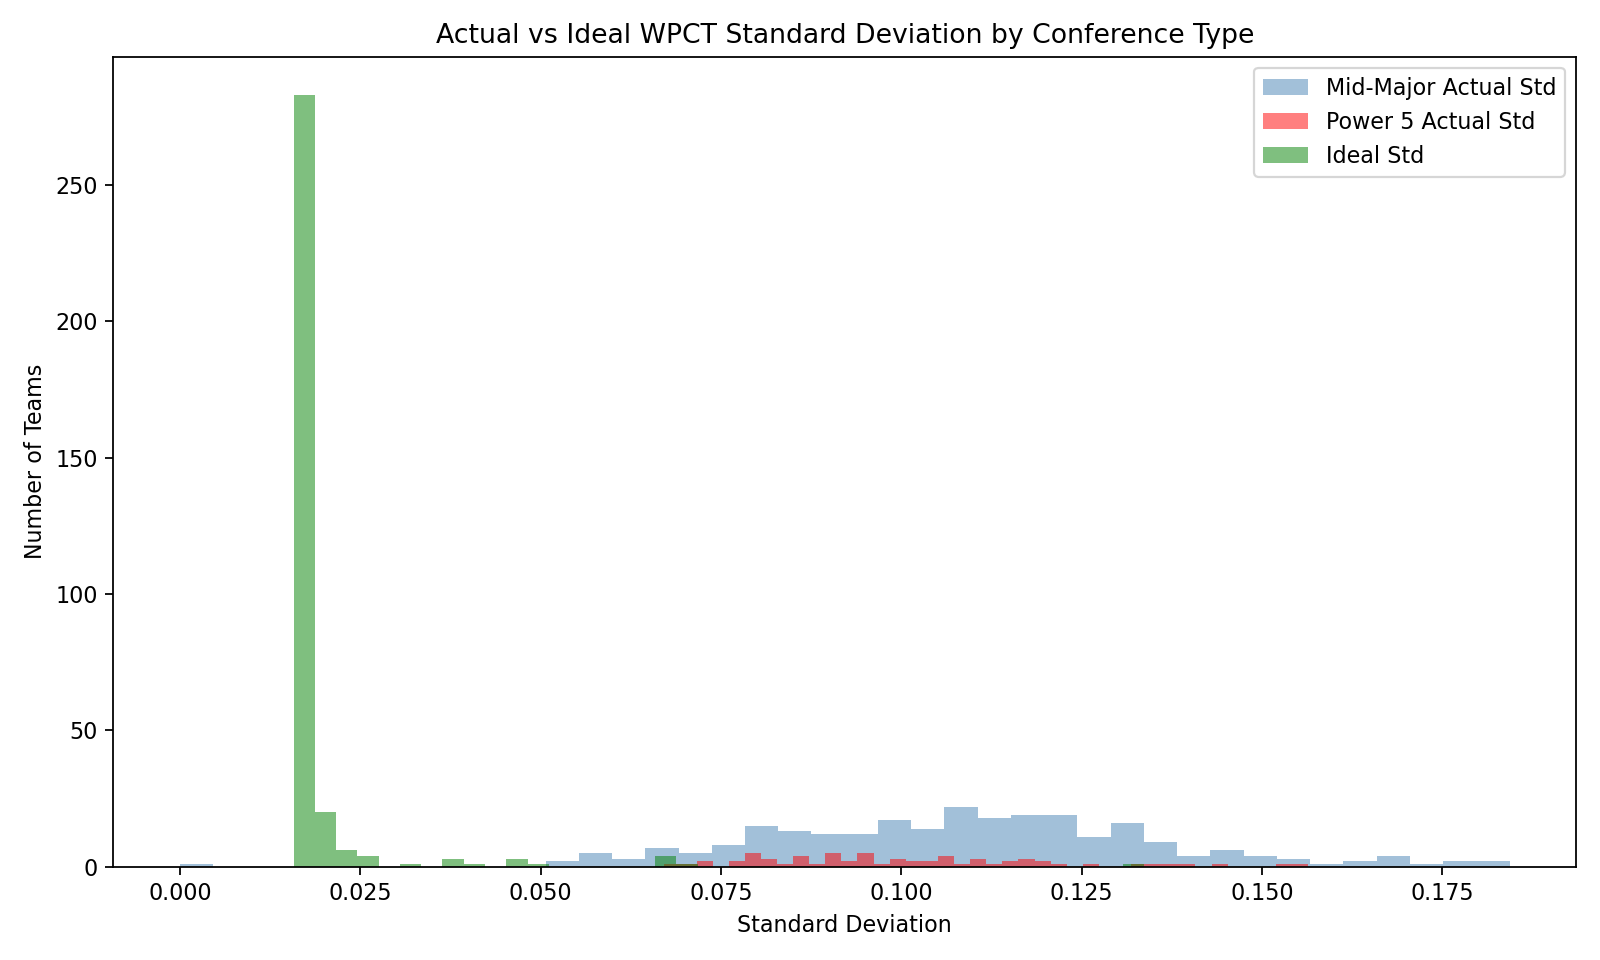

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  5.,
         3.,  7.,  5.,  8., 15., 13., 12., 12., 17., 14., 22., 18., 19.,
        19., 11., 16.,  9.,  4.,  6.,  4.,  3.,  1.,  2.,  4.,  1.,  2.,
         2.]),
 array([0.        , 0.0046079 , 0.00921579, 0.01382369, 0.01843159,
        0.02303948, 0.02764738, 0.03225528, 0.03686317, 0.04147107,
        0.04607897, 0.05068687, 0.05529476, 0.05990266, 0.06451056,
        0.06911845, 0.07372635, 0.07833425, 0.08294214, 0.08755004,
        0.09215794, 0.09676583, 0.10137373, 0.10598163, 0.11058952,
        0.11519742, 0.11980532, 0.12441322, 0.12902111, 0.13362901,
        0.13823691, 0.1428448 , 0.1474527 , 0.1520606 , 0.15666849,
        0.16127639, 0.16588429, 0.17049218, 0.17510008, 0.17970798,
        0.18431587]),
 <BarContainer object of 40 artists>)

(array([1., 1., 2., 0., 2., 5., 3., 1., 4., 1., 5., 2., 5., 1., 3., 2., 2.,
        4., 1., 3., 1., 2., 3., 2., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0.,
        1., 0., 0., 0., 1., 1.]),
 array([0.06715022, 0.06938143, 0.07161264, 0.07384385, 0.07607506,
        0.07830627, 0.08053748, 0.08276869, 0.0849999 , 0.08723111,
        0.08946232, 0.09169353, 0.09392474, 0.09615595, 0.09838716,
        0.10061837, 0.10284958, 0.10508079, 0.10731201, 0.10954322,
        0.11177443, 0.11400564, 0.11623685, 0.11846806, 0.12069927,
        0.12293048, 0.12516169, 0.1273929 , 0.12962411, 0.13185532,
        0.13408653, 0.13631774, 0.13854895, 0.14078016, 0.14301137,
        0.14524258, 0.14747379, 0.149705  , 0.15193621, 0.15416742,
        0.15639863]),
 <BarContainer object of 40 artists>)

(array([283.,  20.,   6.,   4.,   0.,   1.,   0.,   3.,   1.,   0.,   3.,
          1.,   0.,   0.,   0.,   0.,   0.,   4.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([0.01577201, 0.01871847, 0.02166494, 0.0246114 , 0.02755787,
        0.03050433, 0.0334508 , 0.03639726, 0.03934373, 0.0422902 ,
        0.04523666, 0.04818313, 0.05112959, 0.05407606, 0.05702252,
        0.05996899, 0.06291545, 0.06586192, 0.06880838, 0.07175485,
        0.07470131, 0.07764778, 0.08059424, 0.08354071, 0.08648718,
        0.08943364, 0.09238011, 0.09532657, 0.09827304, 0.1012195 ,
        0.10416597, 0.10711243, 0.1100589 , 0.11300536, 0.11595183,
        0.11889829, 0.12184476, 0.12479122, 0.12773769, 0.13068416,
        0.13363062]),
 <BarContainer object of 40 artists>)

Text(0.5, 1.0, 'Actual vs Ideal WPCT Standard Deviation by Conference Type')

Text(0.5, 0, 'Standard Deviation')

Text(0, 0.5, 'Number of Teams')

In [202]:
#Create overlapped histogram to show ideal std vs actual std with Power 5 conferences highlighted
fig, ax = plt.subplots(figsize=(10, 6))

mid_major = combined[combined['Power5'] == False]['W/L%_std']
power5 = combined[combined['Power5'] == True]['W/L%_std']
ideal = combined['ideal_std']

ax.hist(mid_major, bins=40, alpha=0.5, color='steelblue', label='Mid-Major Actual Std')
ax.hist(power5, bins=40, alpha=0.5, color='red', label='Power 5 Actual Std')
ax.hist(ideal, bins=40, alpha=0.5, color='green', label='Ideal Std')

ax.set_title("Actual vs Ideal WPCT Standard Deviation by Conference Type")
ax.set_xlabel("Standard Deviation")
ax.set_ylabel("Number of Teams")
ax.legend()

plt.tight_layout()
fig.savefig("idealvsactual.pdf")
plt.show()

<IPython.core.display.Javascript object>


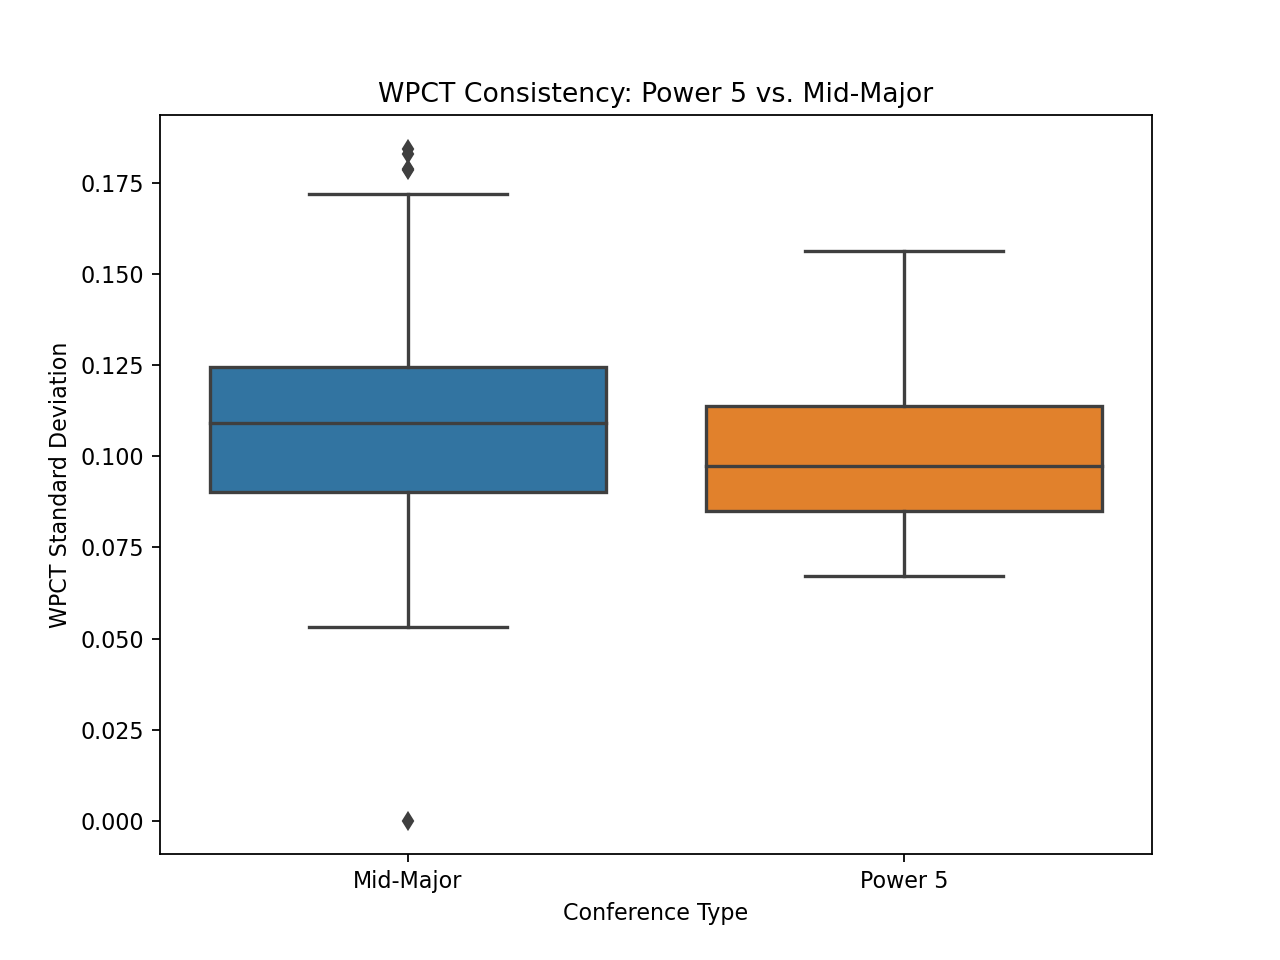

<Axes: xlabel='Conference Type', ylabel='W/L%_std'>

Text(0.5, 1.0, 'WPCT Consistency: Power 5 vs. Mid-Major')

Text(0, 0.5, 'WPCT Standard Deviation')

In [203]:
#Create side-by-side box plot to show the variance of win percentage
import seaborn as sns

team_consistency['Conference Type'] = team_consistency['Power5'].astype(int).map({1:'Power 5', 0:'Mid-Major'})

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=team_consistency, x='Conference Type', y='W/L%_std', ax=ax)
ax.set_title('WPCT Consistency: Power 5 vs. Mid-Major')
ax.set_ylabel('WPCT Standard Deviation')                
plt.show()
fig.savefig("win_consistency.pdf")

In [204]:
#Calculate Roster Continuity - batting and pitching seperate

batting['returning'] = batting.groupby('name')['year'].diff() == 1

batting_continuity = batting.groupby(['team name','year']).apply(
    lambda x: x.loc[x['returning'], 'pa'].sum() / x['pa'].sum()
).reset_index(name='batting_continuity')

batting_continuity


pitching['returning'] = pitching.groupby('name')['year'].diff() == 1

pitching_continuity = pitching.groupby(['team name','year']).apply(
    lambda x: x.loc[x['returning'], 'ip'].sum() / x['ip'].sum()
).reset_index(name='pitching_continuity')

pitching_continuity



,team name,year,batting_continuity
0,Abilene Christian University,2021,0.000000
1,Abilene Christian University,2022,0.725011
2,Abilene Christian University,2023,0.505063
3,Abilene Christian University,2024,0.431126
4,Abilene Christian University,2025,0.394076
...,...,...,...
1472,Youngstown State University,2021,0.000000
1473,Youngstown State University,2022,0.602623
1474,Youngstown State University,2023,0.659216
1475,Youngstown State University,2024,0.584246


,team name,year,pitching_continuity
0,Abilene Christian University,2021,0.000000
1,Abilene Christian University,2022,0.762935
2,Abilene Christian University,2023,0.811149
3,Abilene Christian University,2024,0.457108
4,Abilene Christian University,2025,0.898355
...,...,...,...
1463,Youngstown State University,2021,0.000000
1464,Youngstown State University,2022,0.859672
1465,Youngstown State University,2023,0.496637
1466,Youngstown State University,2024,0.625797


In [205]:
#Merge batting and pitching
continuity = pd.merge(
    batting_continuity,
    pitching_continuity,
    on=['team name','year']
)


In [206]:
#Create total roster continuity variable
continuity['roster_continuity'] = (continuity['batting_continuity']+continuity['pitching_continuity'])/2
continuity


,team name,year,batting_continuity,pitching_continuity,roster_continuity
0,Abilene Christian University,2021,0.000000,0.000000,0.000000
1,Abilene Christian University,2022,0.725011,0.762935,0.743973
2,Abilene Christian University,2023,0.505063,0.811149,0.658106
3,Abilene Christian University,2024,0.431126,0.457108,0.444117
4,Abilene Christian University,2025,0.394076,0.898355,0.646215
...,...,...,...,...,...
1417,Youngstown State University,2021,0.000000,0.000000,0.000000
1418,Youngstown State University,2022,0.602623,0.859672,0.731148
1419,Youngstown State University,2023,0.659216,0.496637,0.577927
1420,Youngstown State University,2024,0.584246,0.625797,0.605021


<IPython.core.display.Javascript object>


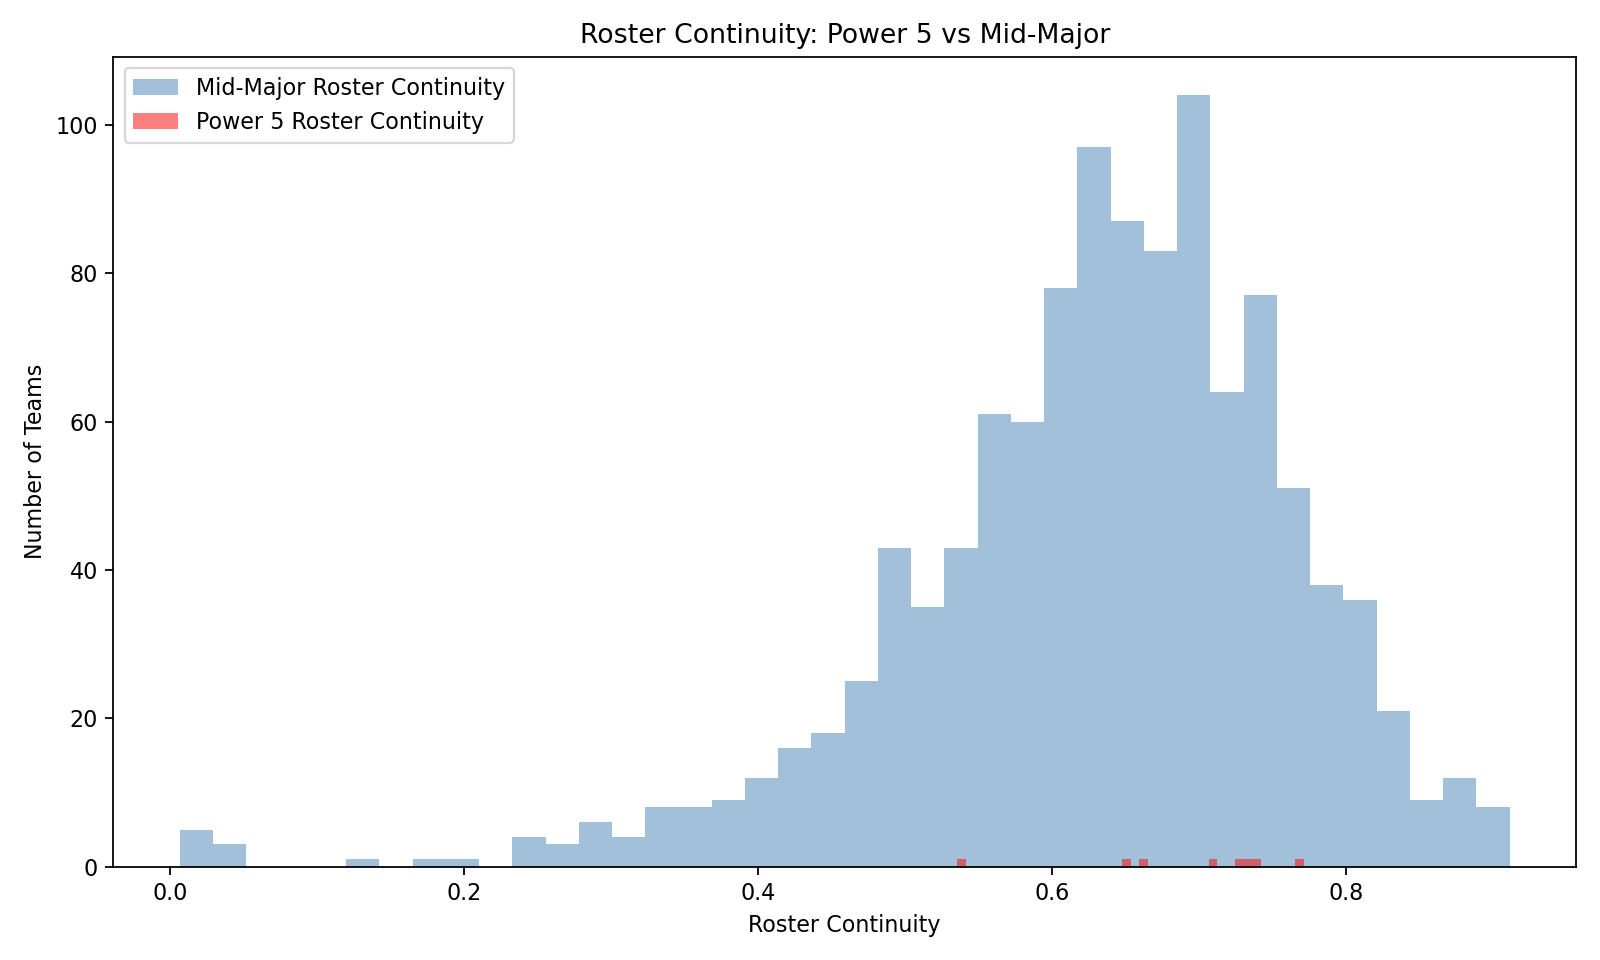

(array([  5.,   3.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   0.,   4.,
          3.,   6.,   4.,   8.,   8.,   9.,  12.,  16.,  18.,  25.,  43.,
         35.,  43.,  61.,  60.,  78.,  97.,  87.,  83., 104.,  64.,  77.,
         51.,  38.,  36.,  21.,   9.,  12.,   8.]),
 array([0.00647878, 0.02909088, 0.05170297, 0.07431507, 0.09692716,
        0.11953925, 0.14215135, 0.16476344, 0.18737554, 0.20998763,
        0.23259973, 0.25521182, 0.27782392, 0.30043601, 0.32304811,
        0.3456602 , 0.3682723 , 0.39088439, 0.41349648, 0.43610858,
        0.45872067, 0.48133277, 0.50394486, 0.52655696, 0.54916905,
        0.57178115, 0.59439324, 0.61700534, 0.63961743, 0.66222953,
        0.68484162, 0.70745371, 0.73006581, 0.7526779 , 0.77529   ,
        0.79790209, 0.82051419, 0.84312628, 0.86573838, 0.88835047,
        0.91096257]),
 <BarContainer object of 40 artists>)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1.,
        1., 0., 0., 0., 0., 1.]),
 array([0.53538434, 0.54127568, 0.54716703, 0.55305837, 0.55894971,
        0.56484105, 0.57073239, 0.57662374, 0.58251508, 0.58840642,
        0.59429776, 0.60018911, 0.60608045, 0.61197179, 0.61786313,
        0.62375448, 0.62964582, 0.63553716, 0.6414285 , 0.64731984,
        0.65321119, 0.65910253, 0.66499387, 0.67088521, 0.67677656,
        0.6826679 , 0.68855924, 0.69445058, 0.70034192, 0.70623327,
        0.71212461, 0.71801595, 0.72390729, 0.72979864, 0.73568998,
        0.74158132, 0.74747266, 0.75336401, 0.75925535, 0.76514669,
        0.77103803]),
 <BarContainer object of 40 artists>)

Text(0.5, 1.0, 'Roster Continuity: Power 5 vs Mid-Major')

Text(0.5, 0, 'Roster Continuity')

Text(0, 0.5, 'Number of Teams')

In [211]:
#Specify which teams are part of the Power 5 conferences, the csv files we used for batting and pitching
#didn't have conference name, so I specified each team individually
Power5 = ('Boston College', 'California', 'Clemson', 'Duke', 'Florida State',
          'Georgia Tech', 'Louisville', 'Miami', 'NC State', 'North Carolina', 'Pittsburgh', 'SMU',
          'Stanford', 'Syracuse', 'Virginia', 'Virginia Tech', 'Wake Forest','Illinois', 
          'Indiana', 'Iowa', 'Maryland', 'Michigan', 'Michigan State', 'Minnesota', 'Nebraska',
          'Northwestern', 'Ohio State', 'Oregon', 'Penn State', 'Purdue', 'Rutgers', 'UCLA', 'USC', 
          'Washington', 'Wisconsin','Arizona', 'Arizona State', 'Baylor', 'BYU', 'Cincinnati', 'Colorado', 
          'Houston', 'Iowa State', 'Kansas', 'Kansas State', 'Oklahoma State', 'TCU', 'Texas Tech', 'UCF', 
          'Utah', 'West Virginia','Alabama', 'Arkansas', 'Auburn', 'Florida', 'Georgia', 'Kentucky', 'LSU', 
          'Mississippi State', 'Missouri', 'Oklahoma', 'Ole Miss', 'South Carolina', 'Tennessee', 'Texas', 
          'Texas A&M', 'Vanderbilt')
continuity['Power5']= continuity['team name'].isin(Power5).astype(int)
#2010 was the first year in our data so automatically had a 0 roster continuity. I removed 2010 so it wouldn't
#show as an outlier
continuity = continuity[continuity['roster_continuity'] > 0].copy()

#Create histogram of roster continuity with power 5 conferences highlighted in red
fig, ax = plt.subplots(figsize=(10, 6))

mid_major = continuity[continuity['Power5'] == False]['roster_continuity']
power5 = continuity[continuity['Power5'] == True]['roster_continuity']


ax.hist(mid_major, bins=40, alpha=0.5, color='steelblue', label='Mid-Major Roster Continuity')
ax.hist(power5, bins=40, alpha=0.5, color='red', label='Power 5 Roster Continuity')

ax.set_title("Roster Continuity: Power 5 vs Mid-Major")
ax.set_xlabel("Roster Continuity")
ax.set_ylabel("Number of Teams")
ax.legend()

plt.tight_layout()
fig.savefig("roster_continuity.pdf")
plt.show()